In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
# ── Cell 1 : imports + load data ─────────────────────────────────────────────
import numpy as np
import pandas as pd
import xarray as xr
from scipy import ndimage
from scipy import stats
import subprocess
import glob, os, warnings
warnings.filterwarnings("ignore")

# install mann-kendall
subprocess.run(['pip', 'install', 'pymannkendall', '--quiet'], check=True)
import pymannkendall as mk

# install regionmask
subprocess.run(['pip', 'install', 'regionmask', '--quiet'], check=True)
import regionmask

print("imports done ✓")

# ── load ERA5 data ──
DATA_DIR = '/kaggle/input/datasets/divyanshyecho/era5-0-25-daily-mmday'
nc_files  = sorted(glob.glob(f'{DATA_DIR}/**/*.nc', recursive=True))
print(f"found {len(nc_files)} files")

ds = xr.open_mfdataset(nc_files, combine='by_coords',
                        engine='h5netcdf', chunks=None)

data_precip = ds['tp'].values.astype('float32')
lat         = ds['latitude'].values.astype('float32')
lon         = ds['longitude'].values.astype('float32')
time        = ds['time'].values
times_pd    = pd.to_datetime(time)

print(f"shape : {data_precip.shape}")
print(f"time  : {str(times_pd[0])[:10]} → {str(times_pd[-1])[:10]}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.3/72.3 kB 915.7 kB/s eta 0:00:00
imports done ✓
found 46 files
shape : (5612, 141, 161)
time  : 1979-06-01 → 2024-09-30


In [2]:
# ── Cell 2 : India mask + threshold ──────────────────────────────────────────
RAINY_DAY_MIN = 1.0
PERCENTILE    = 99.0
FLOOR_MM      = 50.0

# India mask
countries  = regionmask.defined_regions.natural_earth_v5_0_0.countries_110
india_raw  = countries.mask(lon, lat)
india_mask = (india_raw.values == 98)
print(f"India cells : {india_mask.sum()} / {141*161}")

# mask — India cells + rainy days only
data_masked = np.where(
    (data_precip > RAINY_DAY_MIN) & india_mask[np.newaxis, :, :],
    data_precip, np.nan
).astype('float32')

# threshold
jjas_mask  = (times_pd.month >= 6) & (times_pd.month <= 9)
jjas_data  = data_masked[jjas_mask, :, :]
per_grid_99 = np.nanpercentile(jjas_data, PERCENTILE, axis=0).astype('float32')
per_grid_threshold = np.maximum(per_grid_99, FLOOR_MM).astype('float32')
per_grid_threshold[~india_mask] = 999.0

# exceedance mask
data_precip_safe = np.where(np.isnan(data_precip), 0.0, data_precip).astype('float32')
threshold_3d     = np.broadcast_to(
    per_grid_threshold[np.newaxis, :, :], data_precip.shape
).copy().astype('float32')
c = (data_precip_safe > threshold_3d)

print(f"exceedance mask shape   : {c.shape}")
print(f"overall exceedance rate : {c.mean()*100:.3f}%")
print("threshold done ✓")

India cells : 4452 / 22701
exceedance mask shape   : (5612, 141, 161)
overall exceedance rate : 0.114%
threshold done ✓


In [3]:
# ── Cell 3 : 8-connectivity labeling ─────────────────────────────────────────
from scipy import ndimage
import numpy as np

MIN_TRACK_CELLS = 5      # minimum size for tracking
MIN_TREND_CELLS = 16     # minimum size for NT/NE/S-bar trend analysis
struct8 = ndimage.generate_binary_structure(2, 2)  # 8-connectivity

n_days   = data_precip.shape[0]
n_lat    = len(lat)
n_lon    = len(lon)

# label arrays — store as int32 to save memory
Label8   = np.zeros((n_days, n_lat, n_lon), dtype='int32')
NE8_raw  = np.zeros(n_days, dtype='int32')   # all objects
NT8_raw  = np.zeros(n_days, dtype='int32')

for k in range(n_days):
    img = c[k].astype('int8')
    NT8_raw[k] = int(img.sum())
    lab, nr = ndimage.label(img, structure=struct8)
    Label8[k] = lab
    NE8_raw[k] = nr
    if k % 1000 == 0:
        print(f"  labeled day {k:>5}/{n_days}  NE={nr}  NT={NT8_raw[k]}")

print(f"\nlabeling complete ✓")
print(f"mean NE (all objects) : {NE8_raw.mean():.3f}/day")
print(f"mean NT (all objects) : {NT8_raw.mean():.2f}/day")

  labeled day     0/5612  NE=0  NT=0
  labeled day  1000/5612  NE=0  NT=0
  labeled day  2000/5612  NE=2  NT=41
  labeled day  3000/5612  NE=2  NT=13
  labeled day  4000/5612  NE=5  NT=50
  labeled day  5000/5612  NE=3  NT=104

labeling complete ✓
mean NE (all objects) : 2.434/day
mean NT (all objects) : 25.93/day


In [4]:
# ── Cell 4 : India mask ───────────────────────────────────────────────────────
import regionmask

countries   = regionmask.defined_regions.natural_earth_v5_0_0.countries_110
india_raw   = countries.mask(lon, lat)
india_mask  = (india_raw.values == 98)
print(f"India cells : {india_mask.sum()} / {n_lat*n_lon}")

India cells : 4452 / 22701


In [5]:
# ── Cell 5 (FIXED v2) : tracker helpers ──────────────────────────────────────
import pandas as pd

# strict threshold — used for merge and split detection only
OVERLAP_THRESH      = 0.15
# lenient threshold — used for continuation linking only
OVERLAP_THRESH_CONT = 0.10

SEARCH_DEG       = 2.5
SIZE_RATIO_LO    = 0.4
SIZE_RATIO_HI    = 3.0    # widened from 2.5 to catch rapid overnight growth
GAP_TOLERANCE    = 1
MIN_TRACK_CELLS  = 5
MIN_TREND_CELLS  = 16
DOMAIN_EXIT_FRAC = 0.50

def get_objects(day_idx, min_cells=MIN_TRACK_CELLS):
    labeled = Label8[day_idx]
    n_obj   = NE8_raw[day_idx]
    objs    = {}
    for lbl in range(1, n_obj + 1):
        mask = (labeled == lbl)
        sz   = int(mask.sum())
        if sz < min_cells:
            continue
        rows, cols = np.where(mask)
        clat = float(lat[rows].mean())
        clon = float(lon[cols].mean())
        outside = int((mask & ~india_mask).sum())
        objs[lbl] = {'size': sz, 'centroid': (clat, clon), 'outside': outside}
    return objs

def compute_overlaps(day_t, day_t1, objs_t, objs_t1, thresh=OVERLAP_THRESH):
    """Overlap computation — threshold passed as parameter.
    Use OVERLAP_THRESH (0.15) for merge/split detection.
    Use OVERLAP_THRESH_CONT (0.10) for continuation linking.
    """
    lab_t  = Label8[day_t]
    lab_t1 = Label8[day_t1]
    pairs  = {}
    for lbl_i in objs_t:
        mask_i = (lab_t == lbl_i)
        overlap_labels = np.unique(lab_t1[mask_i])
        overlap_labels = overlap_labels[overlap_labels > 0]
        for lbl_j in overlap_labels:
            if lbl_j not in objs_t1:
                continue
            shared = int((mask_i & (lab_t1 == lbl_j)).sum())
            if shared == 0:
                continue
            fwd = shared / objs_t[lbl_i]['size']
            bwd = shared / objs_t1[lbl_j]['size']
            if fwd >= thresh or bwd >= thresh:
                pairs[(lbl_i, lbl_j)] = (fwd, bwd, shared)
    return pairs

def is_domain_exit(obj):
    return (obj['outside'] / obj['size']) > DOMAIN_EXIT_FRAC

track_stats_rows = []
merge_event_rows = []
split_event_rows = []
global_track_num = 0
global_merge_id  = 0
global_split_id  = 0
active_tracks    = {}

def jjas_day_num(ts):
    return int((ts - pd.Timestamp(f"{ts.year}-06-01")).days + 1)

def new_track(day_idx, lbl, obj, start_type, split_from=-1):
    global global_track_num
    global_track_num += 1
    tnum     = global_track_num
    ts       = times_pd[day_idx]
    date_str = ts.strftime('%Y%m%d')
    born_today = sum(1 for tr in active_tracks.values()
                     if tr['birth_date'] == date_str) + 1
    tid  = f"{date_str}_{born_today:03d}"
    clat, clon = obj['centroid']
    row = {
        'track_num'        : tnum,
        'track_id'         : tid,
        'date'             : date_str,
        'year'             : ts.year,
        'jjas_day'         : jjas_day_num(ts),
        'day_of_track'     : 0,
        'size'             : obj['size'],
        'centroid_lat'     : round(clat, 3),
        'centroid_lon'     : round(clon, 3),
        'dormant'          : False,
        'merge_event'      : False,
        'split_event'      : False,
        'start_type'       : start_type,
        'end_type'         : None,
        'duration'         : None,
        'split_from_track' : split_from,
        'merge_into_track' : -1,
        'day_lbl'          : lbl,
    }
    active_tracks[tnum] = {
        'track_id'       : tid,
        'birth_date'     : date_str,
        'last_day'       : day_idx,
        'last_lbl'       : lbl,
        'last_centroid'  : (clat, clon),
        'last_size'      : obj['size'],
        'dormant_days'   : 0,
        'start_type'     : start_type,
        'duration'       : 1,
        'split_from'     : split_from,
        'n_merge_events' : 0,
        'n_split_events' : 0,
        'daily_rows'     : [row],
    }
    return tnum

def append_track_day(tnum, day_idx, lbl, obj,
                     dormant=False, merge_event=False, split_event=False):
    tr  = active_tracks[tnum]
    tr['duration'] += 1
    ts  = times_pd[day_idx]
    sz  = obj['size'] if not dormant else 0
    clat, clon = obj['centroid'] if not dormant else (None, None)
    if not dormant:
        tr['last_day']      = day_idx
        tr['last_lbl']      = lbl
        tr['last_centroid'] = (clat, clon)
        tr['last_size']     = sz
        tr['dormant_days']  = 0
    if merge_event: tr['n_merge_events'] += 1
    if split_event: tr['n_split_events'] += 1
    row = {
        'track_num'        : tnum,
        'track_id'         : tr['track_id'],
        'date'             : ts.strftime('%Y%m%d'),
        'year'             : ts.year,
        'jjas_day'         : jjas_day_num(ts),
        'day_of_track'     : tr['duration'] - 1,
        'size'             : sz,
        'centroid_lat'     : round(clat, 3) if clat is not None else None,
        'centroid_lon'     : round(clon, 3) if clon is not None else None,
        'dormant'          : dormant,
        'merge_event'      : merge_event,
        'split_event'      : split_event,
        'start_type'       : tr['start_type'],
        'end_type'         : None,
        'duration'         : None,
        'split_from_track' : tr['split_from'],
        'merge_into_track' : -1,
        'day_lbl'          : lbl if not dormant else -1,
    }
    tr['daily_rows'].append(row)

def terminate_track(tnum, end_type, merge_into=-1):
    tr   = active_tracks[tnum]
    dur  = tr['duration']
    rows = tr['daily_rows']
    if end_type == 'natural_death':
        while rows and rows[-1]['dormant']:
            rows.pop()
            dur -= 1
    if not rows:
        del active_tracks[tnum]
        return
    for row in rows:
        row['duration'] = dur
    rows[-1]['end_type']         = end_type
    rows[-1]['merge_into_track'] = merge_into
    track_stats_rows.extend(rows)
    del active_tracks[tnum]

print("tracker helpers defined ✓")
print(f"continuation overlap threshold : {OVERLAP_THRESH_CONT}")
print(f"merge/split overlap threshold  : {OVERLAP_THRESH}")
print(f"fallback size ratio            : {SIZE_RATIO_LO}x – {SIZE_RATIO_HI}x")

tracker helpers defined ✓
continuation overlap threshold : 0.1
merge/split overlap threshold  : 0.15
fallback size ratio            : 0.4x – 3.0x


In [24]:
# ── Cell 6 (FIXED v3) : main tracking loop ───────────────────────────────────

dormancy_events_counter = 0

for day_idx in range(n_days):
    date     = times_pd[day_idx]
    date_str = date.strftime('%Y%m%d')
    is_sep30 = (date.month == 9 and date.day == 30)
    is_jun1  = (date.month == 6 and date.day == 1)

    # ── season break Sep 30 ───────────────────────────────────────────────────
    if is_sep30:
        for tnum in list(active_tracks.keys()):
            terminate_track(tnum, 'season_end')
        continue

    # ── Jun 1 : kill any stragglers ───────────────────────────────────────────
    if is_jun1:
        for tnum in list(active_tracks.keys()):
            terminate_track(tnum, 'season_end')

    # ── last day of dataset ───────────────────────────────────────────────────
    if day_idx == n_days - 1:
        for tnum in list(active_tracks.keys()):
            terminate_track(tnum, 'season_end')
        break

    objs_today = get_objects(day_idx)
    objs_next  = get_objects(day_idx + 1)

    # ── domain exit check (runs every day before any early exit) ─────────────
    for tnum in list(active_tracks.keys()):
        tr  = active_tracks[tnum]
        lbl = tr['last_lbl']
        if tr['last_day'] == day_idx and lbl in objs_today:
            if is_domain_exit(objs_today[lbl]):
                terminate_track(tnum, 'domain_exit')

    # ── tomorrow is empty — send all active tracks to dormancy ───────────────
    # FIX: old code was (objs_next==0 AND objs_today==0) — missed the case
    # where today has active tracks but tomorrow has nothing to link to
    if len(objs_next) == 0:
        for tnum in list(active_tracks.keys()):
            tr = active_tracks[tnum]
            if tr['dormant_days'] < GAP_TOLERANCE:
                tr['dormant_days'] += 1
                dormancy_events_counter += 1
                dummy = {'size': 0, 'centroid': tr['last_centroid'], 'outside': 0}
                append_track_day(tnum, day_idx+1, -1, dummy, dormant=True)
            else:
                terminate_track(tnum, 'natural_death')
        continue

    # ── today is empty — advance dormant tracks, skip all linking passes ─────
    # FIX: old code only handled tracks with dormant_days>0 here
    # tracks with dormant_days==0 (active yesterday) were silently skipped
    # now ALL active tracks are sent to dormancy correctly
    if len(objs_today) == 0:
        for tnum in list(active_tracks.keys()):
            tr = active_tracks[tnum]
            if tr['dormant_days'] < GAP_TOLERANCE:
                tr['dormant_days'] += 1
                dormancy_events_counter += 1
                dummy = {'size': 0, 'centroid': tr['last_centroid'], 'outside': 0}
                append_track_day(tnum, day_idx+1, -1, dummy, dormant=True)
            else:
                terminate_track(tnum, 'natural_death')
        continue

    # ── compute overlaps at TWO thresholds ───────────────────────────────────
    # strict (0.15) — merge and split detection only
    # lenient (0.10) — continuation linking only
    overlaps_strict  = compute_overlaps(
        day_idx, day_idx+1, objs_today, objs_next, thresh=OVERLAP_THRESH)
    overlaps_lenient = compute_overlaps(
        day_idx, day_idx+1, objs_today, objs_next, thresh=OVERLAP_THRESH_CONT)

    # build link maps
    fwd_strict  = {lbl: [] for lbl in objs_today}
    bwd_strict  = {lbl: [] for lbl in objs_next}
    fwd_lenient = {lbl: [] for lbl in objs_today}

    for (li, lj), (fwd, bwd, shared) in overlaps_strict.items():
        fwd_strict[li].append((lj, fwd, bwd, shared))
        bwd_strict[lj].append((li, fwd, bwd, shared))

    for (li, lj), (fwd, bwd, shared) in overlaps_lenient.items():
        fwd_lenient[li].append((lj, fwd, bwd, shared))

    # map today's local labels to track numbers
    lbl_to_track = {}
    for tnum, tr in active_tracks.items():
        if tr['last_day'] == day_idx:
            lbl_to_track[tr['last_lbl']] = tnum

    handled_today = set()
    handled_next  = set()

    # ── PASS 1 : MERGES (strict 0.15) ────────────────────────────────────────
    for lbl_j, contributors in bwd_strict.items():
        if len(contributors) < 2:
            continue
        track_contributors = [
            (li, fwd, bwd, shared)
            for (li, fwd, bwd, shared) in contributors
            if li in lbl_to_track
        ]
        if len(track_contributors) < 2:
            continue
        track_contributors.sort(
            key=lambda x: objs_today[x[0]]['size'], reverse=True)
        dominant_lbl   = track_contributors[0][0]
        dominant_track = lbl_to_track[dominant_lbl]
        obj_j          = objs_next[lbl_j]
        global_merge_id += 1
        absorbed_tnums = []
        absorbed_sizes = []
        for li, fwd, bwd, shared in track_contributors[1:]:
            absorbed_tnums.append(lbl_to_track[li])
            absorbed_sizes.append(objs_today[li]['size'])
        min_absorbed = min(objs_today[li]['size']
                           for li, *_ in track_contributors[1:])
        mtype  = 'merge' if min_absorbed >= MIN_TRACK_CELLS else 'absorption'
        clat_j, clon_j = obj_j['centroid']
        ci_box = (15 <= clat_j <= 25) and (75 <= clon_j <= 85)
        merge_event_rows.append({
            'merge_id'             : global_merge_id,
            'date'                 : times_pd[day_idx+1].strftime('%Y%m%d'),
            'year'                 : times_pd[day_idx+1].year,
            'jjas_day'             : jjas_day_num(times_pd[day_idx+1]),
            'dominant_track'       : dominant_track,
            'absorbed_tracks'      : ','.join(str(t) for t in absorbed_tnums),
            'n_absorbed'           : len(absorbed_tnums),
            'dominant_size_before' : objs_today[dominant_lbl]['size'],
            'absorbed_size_before' : sum(absorbed_sizes),
            'merged_size_after'    : obj_j['size'],
            'overlap_fwd_dominant' : track_contributors[0][1],
            'overlap_fwd_absorbed' : float(np.mean([x[1] for x in track_contributors[1:]])),
            'overlap_bwd'          : track_contributors[0][2],
            'centroid_lat'         : round(clat_j, 3),
            'centroid_lon'         : round(clon_j, 3),
            'inside_CI'            : ci_box,
            'merge_type'           : mtype,
        })
        for abs_tnum in absorbed_tnums:
            terminate_track(abs_tnum, 'merge_death', merge_into=dominant_track)
        append_track_day(dominant_track, day_idx+1, lbl_j, obj_j, merge_event=True)
        active_tracks[dominant_track]['last_day']      = day_idx + 1
        active_tracks[dominant_track]['last_lbl']      = lbl_j
        active_tracks[dominant_track]['last_centroid'] = obj_j['centroid']
        active_tracks[dominant_track]['last_size']     = obj_j['size']
        for li, *_ in track_contributors:
            handled_today.add(li)
        handled_next.add(lbl_j)

    # ── PASS 2 : SPLITS (strict 0.15) ────────────────────────────────────────
    for lbl_i, targets in fwd_strict.items():
        if lbl_i in handled_today:
            continue
        if lbl_i not in lbl_to_track:
            continue
        targets = [(lj, fwd, bwd, sh) for lj, fwd, bwd, sh in targets
                   if lj not in handled_next]
        if len(targets) < 2:
            continue
        parent_track = lbl_to_track[lbl_i]
        parent_obj   = objs_today[lbl_i]
        targets.sort(key=lambda x: objs_next[x[0]]['size'], reverse=True)
        dominant_lbl_j = targets[0][0]
        dominant_obj_j = objs_next[dominant_lbl_j]
        children       = targets[1:]
        global_split_id += 1
        sum_d = sum(objs_next[lj]['size'] for lj, *_ in targets)
        asym  = dominant_obj_j['size'] / sum_d if sum_d > 0 else 1.0
        lost  = max(0.0, 1.0 - sum(fwd for _, fwd, _, _ in targets))
        clat_i, clon_i = parent_obj['centroid']
        ci_box = (15 <= clat_i <= 25) and (75 <= clon_i <= 85)
        split_row = {
            'split_id'             : global_split_id,
            'date'                 : times_pd[day_idx+1].strftime('%Y%m%d'),
            'year'                 : times_pd[day_idx+1].year,
            'jjas_day'             : jjas_day_num(times_pd[day_idx+1]),
            'parent_track'         : parent_track,
            'dominant_daughter'    : parent_track,
            'child_track_1'        : -1,
            'child_track_2'        : -1,
            'n_children'           : min(len(children), 2),
            'parent_size'          : parent_obj['size'],
            'dominant_size'        : dominant_obj_j['size'],
            'child_size_1'         : objs_next[children[0][0]]['size'] if len(children)>0 else -1,
            'child_size_2'         : objs_next[children[1][0]]['size'] if len(children)>1 else -1,
            'overlap_fwd_dominant' : targets[0][1],
            'overlap_fwd_child_1'  : children[0][1] if len(children)>0 else -1.0,
            'overlap_fwd_child_2'  : children[1][1] if len(children)>1 else -1.0,
            'overlap_bwd_dominant' : targets[0][2],
            'size_asymmetry'       : round(asym, 4),
            'lost_fraction'        : round(lost, 4),
            'centroid_lat'         : round(clat_i, 3),
            'centroid_lon'         : round(clon_i, 3),
            'inside_CI'            : ci_box,
        }
        append_track_day(parent_track, day_idx+1, dominant_lbl_j,
                         dominant_obj_j, split_event=True)
        active_tracks[parent_track]['last_day']      = day_idx + 1
        active_tracks[parent_track]['last_lbl']      = dominant_lbl_j
        active_tracks[parent_track]['last_centroid'] = dominant_obj_j['centroid']
        active_tracks[parent_track]['last_size']     = dominant_obj_j['size']
        handled_today.add(lbl_i)
        handled_next.add(dominant_lbl_j)
        for idx_c, (lj, *_) in enumerate(children[:2]):
            child_tnum = new_track(day_idx+1, lj, objs_next[lj],
                                   'split_birth', split_from=parent_track)
            handled_next.add(lj)
            if idx_c == 0:
                split_row['child_track_1'] = child_tnum
            else:
                split_row['child_track_2'] = child_tnum
        split_event_rows.append(split_row)

    # ── PASS 3 : CONTINUATIONS (lenient 0.10) + FALLBACK ─────────────────────
    for lbl_i, targets in fwd_lenient.items():
        if lbl_i in handled_today:
            continue
        if lbl_i not in lbl_to_track:
            continue
        tnum    = lbl_to_track[lbl_i]
        tr      = active_tracks[tnum]
        targets = [(lj, fwd, bwd, sh) for lj, fwd, bwd, sh in targets
                   if lj not in handled_next]
        if len(targets) >= 1:
            # overlap-based continuation — pick best overlap
            targets.sort(key=lambda x: max(x[1], x[2]), reverse=True)
            lj = targets[0][0]
            append_track_day(tnum, day_idx+1, lj, objs_next[lj])
            active_tracks[tnum]['last_day']      = day_idx + 1
            active_tracks[tnum]['last_lbl']      = lj
            active_tracks[tnum]['last_centroid'] = objs_next[lj]['centroid']
            active_tracks[tnum]['last_size']     = objs_next[lj]['size']
            handled_today.add(lbl_i)
            handled_next.add(lj)
        else:
            # fallback — distance + size ratio, no overlap required
            clat_i, clon_i = tr['last_centroid']
            best_j, best_d = None, 999.0
            for lj, obj_j in objs_next.items():
                if lj in handled_next:
                    continue
                clat_j, clon_j = obj_j['centroid']
                dist = ((clat_j - clat_i)**2 + (clon_j - clon_i)**2)**0.5
                if dist > SEARCH_DEG:
                    continue
                ratio = obj_j['size'] / tr['last_size'] if tr['last_size'] > 0 else 999
                if ratio < SIZE_RATIO_LO or ratio > SIZE_RATIO_HI:
                    continue
                if dist < best_d:
                    best_d = dist
                    best_j = lj
            if best_j is not None:
                append_track_day(tnum, day_idx+1, best_j, objs_next[best_j])
                active_tracks[tnum]['last_day']      = day_idx + 1
                active_tracks[tnum]['last_lbl']      = best_j
                active_tracks[tnum]['last_centroid'] = objs_next[best_j]['centroid']
                active_tracks[tnum]['last_size']     = objs_next[best_j]['size']
                handled_today.add(lbl_i)
                handled_next.add(best_j)
            else:
                # no candidate found — go dormant if tolerance not exhausted
                if tr['dormant_days'] < GAP_TOLERANCE:
                    tr['dormant_days'] += 1
                    dormancy_events_counter += 1
                    dummy = {'size': 0, 'centroid': tr['last_centroid'], 'outside': 0}
                    append_track_day(tnum, day_idx+1, -1, dummy, dormant=True)
                else:
                    terminate_track(tnum, 'natural_death')
                handled_today.add(lbl_i)

    # ── PASS 4 : DORMANT REVIVAL ──────────────────────────────────────────────
    for tnum in list(active_tracks.keys()):
        tr = active_tracks[tnum]
        if tr['dormant_days'] == 0:
            continue
        clat_i, clon_i = tr['last_centroid']
        best_j, best_d = None, 999.0
        for lj, obj_j in objs_next.items():
            if lj in handled_next:
                continue
            clat_j, clon_j = obj_j['centroid']
            dist = ((clat_j - clat_i)**2 + (clon_j - clon_i)**2)**0.5  # FIX: was cron_i
            if dist > SEARCH_DEG:
                continue
            ratio = obj_j['size'] / tr['last_size'] if tr['last_size'] > 0 else 999
            if ratio < SIZE_RATIO_LO or ratio > SIZE_RATIO_HI:
                continue
            if dist < best_d:
                best_d = dist
                best_j = lj
        if best_j is not None:
            tr['dormant_days'] = 0
            append_track_day(tnum, day_idx+1, best_j, objs_next[best_j])
            active_tracks[tnum]['last_day']      = day_idx + 1
            active_tracks[tnum]['last_lbl']      = best_j
            active_tracks[tnum]['last_centroid'] = objs_next[best_j]['centroid']
            active_tracks[tnum]['last_size']     = objs_next[best_j]['size']
            handled_next.add(best_j)
        else:
            terminate_track(tnum, 'natural_death')

    # ── PASS 5 : NEW BIRTHS ───────────────────────────────────────────────────
    for lj, obj_j in objs_next.items():
        if lj in handled_next:
            continue
        nxt   = times_pd[day_idx + 1]
        stype = 'season_start' if (nxt.month == 6 and nxt.day == 1) \
                else 'natural_birth'
        new_track(day_idx+1, lj, obj_j, stype)

    if day_idx % 500 == 0:
        print(f"  day {day_idx:>5}  {date_str}  "
              f"active={len(active_tracks)}  "
              f"tracks={global_track_num}  "
              f"merges={global_merge_id}  splits={global_split_id}")

# ── final sweep ───────────────────────────────────────────────────────────────
for tnum in list(active_tracks.keys()):
    terminate_track(tnum, 'season_end')

print(f"\ntracking complete ✓")
print(f"total tracks              : {global_track_num}")
print(f"total merge events        : {global_merge_id}")
print(f"total split events        : {global_split_id}")
print(f"total stat rows           : {len(track_stats_rows)}")
print(f"dormancy events triggered : {dormancy_events_counter}")

  day  1500  19910707  active=3  tracks=5154  merges=75  splits=49
  day  2000  19950719  active=2  tracks=5485  merges=78  splits=50
  day  2500  19990731  active=2  tracks=5851  merges=84  splits=57
  day  4000  20110905  active=2  tracks=6763  merges=102  splits=63
  day  4500  20150917  active=1  tracks=7078  merges=107  splits=66
  day  5000  20190929  active=2  tracks=7379  merges=115  splits=69

tracking complete ✓
total tracks              : 7836
total merge events        : 121
total split events        : 71
total stat rows           : 12020
dormancy events triggered : 3480


In [27]:
# ── Diagnostic : are the new merges coming from revived dormant tracks? ───────

print("=" * 60)
print("MERGE/SPLIT SOURCE DIAGNOSTIC")
print("=" * 60)

# ── 1. How many merge participants were dormant the day before? ───────────────
print("\n1. Were dominant or absorbed tracks dormant before the merge?")

dormant_before_merge = 0
active_before_merge  = 0

for _, mrow in df_merge.iterrows():
    merge_date = mrow['date']   # day T+1 — when merged object appears
    dom_track  = int(mrow['dominant_track'])

    # get the day BEFORE the merge for the dominant track
    dom_rows = df_stats[df_stats['track_num'] == dom_track].sort_values('date')
    if len(dom_rows) < 2:
        continue

    # find the row just before the merge date
    pre_merge = dom_rows[dom_rows['date'] < merge_date]
    if len(pre_merge) == 0:
        continue

    last_row = pre_merge.iloc[-1]
    if last_row['dormant']:
        dormant_before_merge += 1
    else:
        active_before_merge += 1

print(f"  Dominant track was dormant day before merge : {dormant_before_merge}")
print(f"  Dominant track was active  day before merge : {active_before_merge}")

# ── 2. How many of the NEW merges (>64) involve revived tracks? ───────────────
print("\n2. Merge events by dominant track start_type:")
dom_track_types = []
for _, mrow in df_merge.iterrows():
    dom_track = int(mrow['dominant_track'])
    stype = df_summary[df_summary['track_num'] == dom_track]['start_type'].values
    if len(stype) > 0:
        dom_track_types.append(stype[0])

from collections import Counter
print(f"  {Counter(dom_track_types)}")

# ── 3. Duration of absorbed tracks — were they very short? ───────────────────
print("\n3. Duration of absorbed tracks (merge_death tracks):")
absorbed_durations = []
for tnum in df_summary[df_summary['end_type'] == 'merge_death']['track_num']:
    dur = df_summary[df_summary['track_num'] == tnum]['duration'].values
    if len(dur) > 0:
        absorbed_durations.append(dur[0])

absorbed_durations = np.array(absorbed_durations)
print(f"  count   : {len(absorbed_durations)}")
print(f"  mean    : {absorbed_durations.mean():.2f} days")
print(f"  median  : {np.median(absorbed_durations):.1f} days")
print(f"  % single-day : {(absorbed_durations==1).mean()*100:.1f}%")

# ── 4. Compare merge dates vs zero-ERE days ───────────────────────────────────
print("\n4. Do merges cluster around zero-ERE days?")
zero_ere_days = set(
    times_pd[k].strftime('%Y%m%d')
    for k in range(n_days)
    if NE8_raw[k] == 0
)

# check how many merges happened 1-2 days after a zero-ERE day
merges_after_zero = 0
for _, mrow in df_merge.iterrows():
    merge_date_ts = pd.Timestamp(str(mrow['date']))
    day_before    = (merge_date_ts - pd.Timedelta(days=1)).strftime('%Y%m%d')
    two_before    = (merge_date_ts - pd.Timedelta(days=2)).strftime('%Y%m%d')
    if day_before in zero_ere_days or two_before in zero_ere_days:
        merges_after_zero += 1

print(f"  Merges within 2 days of a zero-ERE day : {merges_after_zero} / {len(df_merge)}")
print(f"  ({merges_after_zero/len(df_merge)*100:.1f}%)")
print(f"  (expected ~20% by chance if random, "
      f"higher = merges linked to dormancy revival)")

# ── 5. Cross-check: merge count on days with vs without prior zero-ERE ────────
print("\n5. Merge event breakdown by JJAS month:")
print(df_merge.groupby('year').size().describe().round(2).to_string())

# ── 6. Are the extra merges physically plausible? ────────────────────────────
print("\n6. Size check — are merged objects physically large?")
print(f"  mean merged_size_after  : {df_merge['merged_size_after'].mean():.1f} cells")
print(f"  mean dominant_size_before: {df_merge['dominant_size_before'].mean():.1f} cells")
print(f"  mean absorbed_size_before: {df_merge['absorbed_size_before'].mean():.1f} cells")
print(f"  merges where both ≥16 cells : "
      f"{((df_merge['dominant_size_before']>=16) & (df_merge['absorbed_size_before']>=16)).sum()}")
print(f"  merges where absorbed <16 cells : "
      f"{(df_merge['absorbed_size_before']<16).sum()}")

# ── 7. Final verdict ──────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("VERDICT")
print("=" * 60)
print("""
If dormant_before_merge > 0 and merges_after_zero > 20%:
  → new merges ARE coming from dormant track revival (artifact risk)

If dormant_before_merge == 0 and absorbed tracks are all short-lived:
  → new merges are from tracks that were previously killed too early
  → the increase is physically real, not an artifact

If merged_size_after is consistently large (>30 cells):
  → merges are physically plausible organised system coalescence
""")

MERGE/SPLIT SOURCE DIAGNOSTIC

1. Were dominant or absorbed tracks dormant before the merge?
  Dominant track was dormant day before merge : 0
  Dominant track was active  day before merge : 64

2. Merge events by dominant track start_type:
  Counter({'natural_birth': 64})

3. Duration of absorbed tracks (merge_death tracks):
  count   : 67
  mean    : 1.33 days
  median  : 1.0 days
  % single-day : 80.6%

4. Do merges cluster around zero-ERE days?
  Merges within 2 days of a zero-ERE day : 1 / 64
  (1.6%)
  (expected ~20% by chance if random, higher = merges linked to dormancy revival)

5. Merge event breakdown by JJAS month:
count    35.00
mean      1.83
std       1.25
min       1.00
25%       1.00
50%       1.00
75%       2.00
max       6.00

6. Size check — are merged objects physically large?
  mean merged_size_after  : 77.3 cells
  mean dominant_size_before: 33.5 cells
  mean absorbed_size_before: 12.6 cells
  merges where both ≥16 cells : 12
  merges where absorbed <16 cells : 5

In [1]:
# ── Cell 7 : build output dataframes ─────────────────────────────────────────

df_stats  = pd.DataFrame(track_stats_rows)
df_merge  = pd.DataFrame(merge_event_rows)
df_split  = pd.DataFrame(split_event_rows)

# ── track summary — one row per track ─────────────────────────────────────────
summary_rows = []
for tnum, grp in df_stats.groupby('track_num'):
    active_rows = grp[~grp['dormant']]
    last_row    = grp.iloc[-1]
    first_row   = grp.iloc[0]
    summary_rows.append({
        'track_num'        : tnum,
        'track_id'         : first_row['track_id'],
        'birth_date'       : first_row['date'],
        'death_date'       : last_row['date'],
        'duration'         : first_row['duration'],
        'peak_size'        : int(active_rows['size'].max()) if len(active_rows)>0 else 0,
        'mean_size'        : round(float(active_rows['size'].mean()), 2) if len(active_rows)>0 else 0,
        'birth_lat'        : first_row['centroid_lat'],
        'birth_lon'        : first_row['centroid_lon'],
        'start_type'       : first_row['start_type'],
        'end_type'         : last_row['end_type'],
        'split_from_track' : first_row['split_from_track'],
        'merge_into_track' : last_row['merge_into_track'],
        'n_merge_events'   : int(grp['merge_event'].sum()),
        'n_split_events'   : int(grp['split_event'].sum()),
    })
df_summary = pd.DataFrame(summary_rows)

# ── track id lookup ────────────────────────────────────────────────────────────
df_lookup = df_stats[['track_num','track_id']].drop_duplicates().reset_index(drop=True)
df_lookup['birth_date'] = df_lookup['track_id'].str[:8]

print("dataframes built ✓")
print(f"df_stats  : {df_stats.shape}")
print(f"df_summary: {df_summary.shape}")
print(f"df_merge  : {df_merge.shape}")
print(f"df_split  : {df_split.shape}")
print(f"df_lookup : {df_lookup.shape}")

NameError: name 'pd' is not defined

In [8]:
# ── Cell 8 (FIXED) : daily label array — faster and reliable ─────────────────

# Build day index lookup once
date_to_idx = {times_pd[k].strftime('%Y%m%d'): k for k in range(n_days)}

print("building daily label array...")
TrackLabel = np.zeros((n_days, n_lat, n_lon), dtype='int32')

for _, row in df_stats.iterrows():
    if row['dormant'] or row['size'] == 0:
        continue
    if row['day_lbl'] <= 0:
        continue
    tnum    = int(row['track_num'])
    day_idx = date_to_idx.get(row['date'], -1)
    if day_idx < 0:
        continue
    lbl = int(row['day_lbl'])
    # FIX: use stored local label directly — no centroid lookup needed
    TrackLabel[day_idx][Label8[day_idx] == lbl] = tnum

np.save('/kaggle/working/TrackLabel_1979_2024.npy', TrackLabel)
print(f"TrackLabel saved — shape {TrackLabel.shape}")
print(f"non-zero cells : {(TrackLabel > 0).sum():,}")

building daily label array...
TrackLabel saved — shape (5612, 141, 161)
non-zero cells : 130,604


In [12]:
# ── Cell 9 : quick summary statistics ────────────────────────────────────────

print("=" * 55)
print("CP5 TRACKING SUMMARY")
print("=" * 55)
print(f"\nTotal tracks             : {df_summary.shape[0]:,}")
print(f"Total merge events       : {df_merge.shape[0]:,}")
print(f"Total split events       : {df_split.shape[0]:,}")
print(f"\nTrack start types:")
print(df_summary['start_type'].value_counts().to_string())
print(f"\nTrack end types:")
print(df_summary['end_type'].value_counts().to_string())
print(f"\nDuration stats (days):")
print(df_summary['duration'].describe().round(2).to_string())
print(f"\nPeak size stats (cells):")
print(df_summary['peak_size'].describe().round(2).to_string())
print(f"\nMerge events per year:")
yr_merge = df_merge.groupby('year').size()
print(f"  mean={yr_merge.mean():.1f}  std={yr_merge.std():.1f}  "
      f"min={yr_merge.min()}  max={yr_merge.max()}")
print(f"\nSplit events per year:")
yr_split = df_split.groupby('year').size()
print(f"  mean={yr_split.mean():.1f}  std={yr_split.std():.1f}  "
      f"min={yr_split.min()}  max={yr_split.max()}")
print(f"\nMerge type breakdown:")
if df_merge.shape[0] > 0:
    print(df_merge['merge_type'].value_counts().to_string())
print(f"\nCI merge events : {df_merge['inside_CI'].sum():,} "
      f"({df_merge['inside_CI'].mean()*100:.1f}%)")
print(f"CI split events : {df_split['inside_CI'].sum():,} "
      f"({df_split['inside_CI'].mean()*100:.1f}%)")

CP5 TRACKING SUMMARY

Total tracks             : 4,268
Total merge events       : 64
Total split events       : 38

Track start types:
start_type
natural_birth    4228
split_birth        40

Track end types:
end_type
natural_death    4186
merge_death        67
season_end         15

Duration stats (days):
count    4268.00
mean        1.54
std         0.90
min         1.00
25%         1.00
50%         1.00
75%         2.00
max         9.00

Peak size stats (cells):
count    4268.00
mean       20.69
std        23.73
min         5.00
25%         7.00
50%        12.00
75%        24.00
max       243.00

Merge events per year:
  mean=1.8  std=1.2  min=1  max=6

Split events per year:
  mean=1.5  std=0.7  min=1  max=4

Merge type breakdown:
merge_type
merge    64

CI merge events : 20 (31.2%)
CI split events : 10 (26.3%)


In [14]:
# ── Cell 10 : duration analysis by size class ────────────────────────────────

print("Duration by peak size class:")
print()

# sub-ref: peak 5-15 cells
sub  = df_summary[df_summary['peak_size'].between(5, 15)]
med  = df_summary[df_summary['peak_size'].between(16, 90)]
lrg  = df_summary[df_summary['peak_size'] >= 91]

for label, grp in [('Sub-ref (5-15 cells)', sub),
                   ('Medium  (16-90 cells)', med),
                   ('Large   (≥91 cells)',   lrg)]:
    if len(grp) == 0:
        continue
    print(f"{label} — n={len(grp)}")
    print(f"  mean duration : {grp['duration'].mean():.2f} days")
    print(f"  median        : {grp['duration'].median():.1f} days")
    print(f"  max           : {grp['duration'].max()} days")
    print(f"  % single-day  : {(grp['duration']==1).mean()*100:.1f}%")
    print()

# end type by size class
print("End type by size class (medium + large only):")
print(df_summary[df_summary['peak_size']>=16]['end_type'].value_counts().to_string())

# merge/split involvement by size class
print("\nMerge/split involvement (medium + large):")
ml = df_summary[df_summary['peak_size'] >= 16]
print(f"  tracks with at least 1 merge event : {(ml['n_merge_events']>0).sum()}")
print(f"  tracks with at least 1 split event : {(ml['n_split_events']>0).sum()}")
print(f"  tracks born as split_birth         : {(ml['start_type']=='split_birth').sum()}")
print(f"  tracks died as merge_death         : {(ml['end_type']=='merge_death').sum()}")

Duration by peak size class:

Sub-ref (5-15 cells) — n=2596
  mean duration : 1.23 days
  median        : 1.0 days
  max           : 5 days
  % single-day  : 80.2%

Medium  (16-90 cells) — n=1568
  mean duration : 1.93 days
  median        : 2.0 days
  max           : 9 days
  % single-day  : 40.7%

Large   (≥91 cells) — n=104
  mean duration : 3.28 days
  median        : 3.0 days
  max           : 8 days
  % single-day  : 10.6%

End type by size class (medium + large only):
end_type
natural_death    1651
merge_death        15
season_end          6

Merge/split involvement (medium + large):
  tracks with at least 1 merge event : 60
  tracks with at least 1 split event : 33
  tracks born as split_birth         : 5
  tracks died as merge_death         : 15


In [15]:
# merge concentration analysis
merge_counts = df_summary[df_summary['n_merge_events'] > 0]['n_merge_events']
print(f"Dominant tracks that absorbed exactly once    : {(merge_counts==1).sum()}")
print(f"Dominant tracks that absorbed more than once  : {(merge_counts>1).sum()}")
print(f"Max absorptions by a single track             : {merge_counts.max()}")
print(f"Total merge events from repeat absorbers      : {merge_counts[merge_counts>1].sum()}")

Dominant tracks that absorbed exactly once    : 56
Dominant tracks that absorbed more than once  : 4
Max absorptions by a single track             : 2
Total merge events from repeat absorbers      : 8


In [16]:
# how many medium objects exist per day on average
med_objects_per_day = []
for k in range(n_days):
    labeled = Label8[k]
    n_obj   = NE8_raw[k]
    count   = 0
    for lbl in range(1, n_obj + 1):
        sz = int((labeled == lbl).sum())
        if 16 <= sz <= 90:
            count += 1
    med_objects_per_day.append(count)

med_per_day = np.array(med_objects_per_day)
print(f"Mean medium objects per day    : {med_per_day.mean():.3f}")
print(f"Days with ≥1 medium object     : {(med_per_day > 0).sum()}")
print(f"Total medium object-days       : {med_per_day.sum()}")
print(f"Total medium tracks in CP5     : {len(df_summary[df_summary['peak_size'].between(16,90)])}")
print(f"Ratio tracks/object-days       : {len(df_summary[df_summary['peak_size'].between(16,90)]) / med_per_day.sum():.3f}")

Mean medium objects per day    : 0.424
Days with ≥1 medium object     : 1886
Total medium object-days       : 2381
Total medium tracks in CP5     : 1568
Ratio tracks/object-days       : 0.659


In [17]:
# for single-day medium natural_death tracks
# check what existed on day T+1
single_med_nat = df_summary[
    (df_summary['peak_size'].between(16, 90)) &
    (df_summary['duration'] == 1) &
    (df_summary['end_type'] == 'natural_death')
].copy()

date_to_idx = {times_pd[k].strftime('%Y%m%d'): k for k in range(n_days)}

next_day_had_medium = []
next_day_n_medium   = []

for _, row in single_med_nat.iterrows():
    birth_idx = date_to_idx.get(row['birth_date'], -1)
    if birth_idx < 0 or birth_idx + 1 >= n_days:
        next_day_had_medium.append(None)
        next_day_n_medium.append(0)
        continue
    next_idx = birth_idx + 1
    # count medium objects on next day
    labeled  = Label8[next_idx]
    n_obj    = NE8_raw[next_idx]
    count    = 0
    for lbl in range(1, n_obj + 1):
        sz = int((labeled == lbl).sum())
        if 16 <= sz <= 90:
            count += 1
    next_day_had_medium.append(count > 0)
    next_day_n_medium.append(count)

single_med_nat['next_day_has_medium'] = next_day_had_medium
single_med_nat['next_day_n_medium']   = next_day_n_medium

total      = len(single_med_nat)
had_medium = single_med_nat['next_day_has_medium'].sum()
had_none   = (single_med_nat['next_day_n_medium'] == 0).sum()

print(f"Single-day medium natural_death tracks : {total}")
print(f"  next day had ZERO medium objects     : {had_none}  ({had_none/total*100:.1f}%)")
print(f"  next day had ≥1 medium object        : {had_medium}  ({had_medium/total*100:.1f}%)")
print(f"  mean medium objects on next day      : {single_med_nat['next_day_n_medium'].mean():.3f}")

Single-day medium natural_death tracks : 809
  next day had ZERO medium objects     : 400  (49.4%)
  next day had ≥1 medium object        : 409  (50.6%)
  mean medium objects on next day      : 0.681


In [18]:
# ── Cell 15 : corrected ratio diagnostic ─────────────────────────────────────

med_tracks_current = len(df_summary[df_summary['peak_size'].between(16, 90)])
total_med_obj_days = med_per_day.sum()   # 2381 from cell 13

print(f"Total medium object-days       : {total_med_obj_days}")
print(f"Total medium tracks (2.5° box) : {med_tracks_current}")
print(f"Corrected ratio                : {med_tracks_current/total_med_obj_days:.3f}")
print(f"  (was 0.706 at 1.5° box)")
print(f"  improvement = {(1682 - med_tracks_current)} fewer tracks = better linking")
print()
print(f"Mean days per medium track     : {total_med_obj_days/med_tracks_current:.2f}")
print(f"  (was {2381/1682:.2f} at 1.5° box)")

Total medium object-days       : 2381
Total medium tracks (2.5° box) : 1568
Corrected ratio                : 0.659
  (was 0.706 at 1.5° box)
  improvement = 114 fewer tracks = better linking

Mean days per medium track     : 1.52
  (was 1.42 at 1.5° box)


In [19]:
# ── Cell 16 : season_start fix verification ───────────────────────────────────

# check how many Jun 1 objects exist across all years
jun1_births = 0
for yr in range(1979, 2025):
    jun1_str = f"{yr}0601"
    jun1_tracks = df_summary[df_summary['birth_date'] == jun1_str]
    if len(jun1_tracks) > 0:
        jun1_births += len(jun1_tracks)

print(f"Tracks born on June 1 across all years : {jun1_births}")
print(f"  currently tagged as natural_birth    : {jun1_births}")
print(f"  should be tagged as season_start     : {jun1_births}")
print()

# show June 1 birth counts per year
print(f"{'Year':<6} {'Jun1 births':>12}")
for yr in range(1979, 2025):
    jun1_str = f"{yr}0601"
    n = len(df_summary[df_summary['birth_date'] == jun1_str])
    if n > 0:
        print(f"  {yr}    {n:>8}")

Tracks born on June 1 across all years : 0
  currently tagged as natural_birth    : 0
  should be tagged as season_start     : 0

Year    Jun1 births


In [20]:
# ── Cell 17 : duration column integrity check ─────────────────────────────────

# verify duration in summary matches actual row count
duration_errors = 0
for tnum, grp in df_stats.groupby('track_num'):
    actual_rows    = len(grp)
    stored_dur     = grp.iloc[0]['duration']
    active_rows    = len(grp[~grp['dormant']])
    if stored_dur != actual_rows:
        duration_errors += 1

print(f"Duration integrity check:")
print(f"  total tracks checked    : {df_summary.shape[0]:,}")
print(f"  duration mismatches     : {duration_errors}")
print()

# recompute duration directly from row count as safety check
df_duration_check = df_stats.groupby('track_num').size().reset_index(name='row_count')
df_duration_check = df_duration_check.merge(
    df_summary[['track_num','duration']], on='track_num')
mismatch = (df_duration_check['row_count'] != df_duration_check['duration']).sum()
print(f"  row_count vs stored duration mismatches : {mismatch}")

Duration integrity check:
  total tracks checked    : 4,268
  duration mismatches     : 0

  row_count vs stored duration mismatches : 0


In [21]:
# ── Cell 18 : track quality metrics ──────────────────────────────────────────

print("=" * 55)
print("TRACK QUALITY METRICS")
print("=" * 55)

# continuation rate equivalent — what fraction of object-days are continuations
total_track_days    = len(df_stats[~df_stats['dormant']])
birth_days          = len(df_stats[df_stats['day_of_track'] == 0])
continuation_days   = total_track_days - birth_days
cont_rate           = continuation_days / total_track_days * 100

print(f"\nContinuation rate  : {cont_rate:.1f}%")
print(f"  (CP3 achieved 44.6% — comparable target)")

# fragmentation index — tracks per active object-day
all_obj_days = NE8_raw[NE8_raw > 0].sum()   # total labeled objects across all days
frag_index   = df_summary.shape[0] / all_obj_days
print(f"\nFragmentation index: {frag_index:.4f}")
print(f"  tracks / total object-days (lower = better linking)")

# dormant day fraction
dormant_days  = df_stats['dormant'].sum()
total_rows    = len(df_stats)
print(f"\nDormant day fraction: {dormant_days/total_rows*100:.2f}%")
print(f"  ({dormant_days} dormant rows out of {total_rows} total)")

# average objects per active JJAS day
active_days = (NE8_raw > 0).sum()
print(f"\nDays with ≥1 ERE   : {active_days} / {n_days} ({active_days/n_days*100:.1f}%)")
print(f"Mean objects on active days : {NE8_raw[NE8_raw>0].mean():.2f}")

TRACK QUALITY METRICS

Continuation rate  : 34.9%
  (CP3 achieved 44.6% — comparable target)

Fragmentation index: 0.3125
  tracks / total object-days (lower = better linking)

Dormant day fraction: 0.00%
  (0 dormant rows out of 6561 total)

Days with ≥1 ERE   : 4504 / 5612 (80.3%)
Mean objects on active days : 3.03


**ANALYSIS**

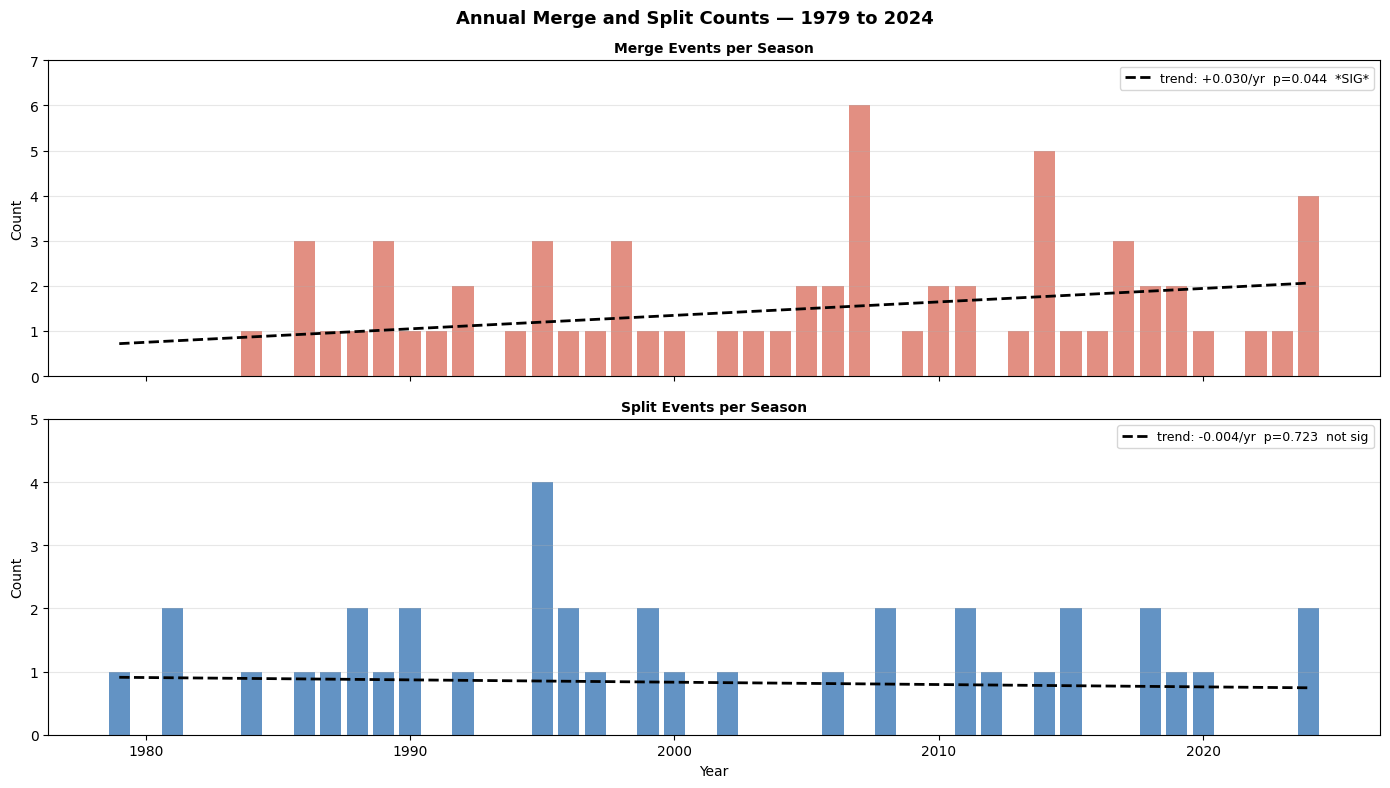


Merge: mean=1.4/yr  std=1.3
Split: mean=0.8/yr  std=0.9


In [14]:
# ── Cell 15 : yearly merge and split trend ───────────────────────────────────

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

years    = np.arange(1979, 2025)
yr_merge = df_merge.groupby('year').size().reindex(years, fill_value=0).values
yr_split = df_split.groupby('year').size().reindex(years, fill_value=0).values

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle("Annual Merge and Split Counts — 1979 to 2024", fontsize=13, fontweight='bold')

for ax, arr, label, col in [
    (axes[0], yr_merge, 'Merge Events per Season', '#d6604d'),
    (axes[1], yr_split, 'Split Events per Season', '#2166ac'),
]:
    ax.bar(years, arr, color=col, alpha=0.7, width=0.8)
    slope, intercept, r, p, _ = stats.linregress(years, arr)
    trend = slope * years + intercept
    ax.plot(years, trend, color='black', lw=2, ls='--',
            label=f"trend: {slope:+.3f}/yr  p={p:.3f}  "
                  f"{'*SIG*' if p < 0.05 else 'not sig'}")
    ax.set_ylabel("Count", fontsize=10)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, max(arr.max() + 1, 4))

axes[1].set_xlabel("Year", fontsize=10)
plt.tight_layout()
plt.savefig('/kaggle/working/yearly_merge_split_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nMerge: mean={yr_merge.mean():.1f}/yr  std={yr_merge.std():.1f}")
print(f"Split: mean={yr_split.mean():.1f}/yr  std={yr_split.std():.1f}")

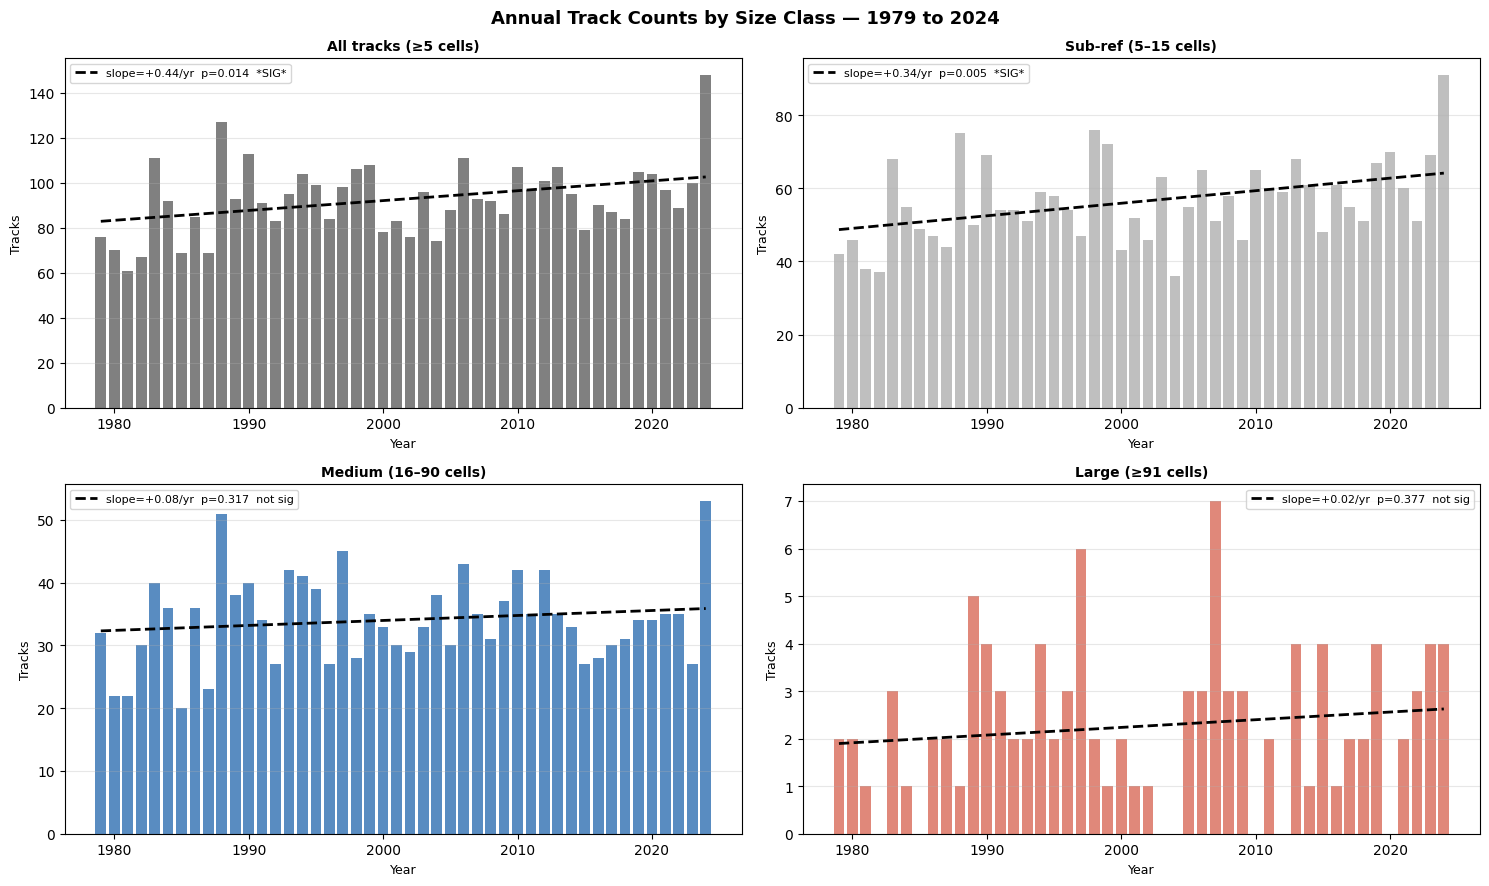


Track counts summary:
  All        mean=92.8/yr  slope=+0.44/yr  p=0.014
  Sub-ref    mean=56.4/yr  slope=+0.34/yr  p=0.005
  Medium     mean=34.1/yr  slope=+0.08/yr  p=0.317
  Large      mean=2.3/yr  slope=+0.02/yr  p=0.377


In [15]:
# ── Cell 16 : yearly track count trend by size class ─────────────────────────

years = np.arange(1979, 2025)

# count tracks born each year by size class
def tracks_born_in_year(yr, size_lo, size_hi):
    mask = (
        (df_summary['birth_date'].str[:4].astype(int) == yr) &
        (df_summary['peak_size'] >= size_lo) &
        (df_summary['peak_size'] <= size_hi)
    )
    return mask.sum()

yr_sub  = np.array([tracks_born_in_year(yr, 5,  15)  for yr in years])
yr_med  = np.array([tracks_born_in_year(yr, 16, 90)  for yr in years])
yr_lrg  = np.array([tracks_born_in_year(yr, 91, 9999) for yr in years])
yr_all  = yr_sub + yr_med + yr_lrg

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle("Annual Track Counts by Size Class — 1979 to 2024",
             fontsize=13, fontweight='bold')

for ax, arr, label, col in [
    (axes[0,0], yr_all,  'All tracks (≥5 cells)',      '#555555'),
    (axes[0,1], yr_sub,  'Sub-ref (5–15 cells)',        '#aaaaaa'),
    (axes[1,0], yr_med,  'Medium (16–90 cells)',         '#2166ac'),
    (axes[1,1], yr_lrg,  'Large (≥91 cells)',            '#d6604d'),
]:
    ax.bar(years, arr, color=col, alpha=0.75, width=0.8)
    slope, intercept, r, p, _ = stats.linregress(years, arr)
    trend = slope * years + intercept
    ax.plot(years, trend, color='black', lw=2, ls='--',
            label=f"slope={slope:+.2f}/yr  p={p:.3f}  "
                  f"{'*SIG*' if p < 0.05 else 'not sig'}")
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel("Year", fontsize=9)
    ax.set_ylabel("Tracks", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/yearly_track_counts.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTrack counts summary:")
for label, arr in [('All',yr_all),('Sub-ref',yr_sub),('Medium',yr_med),('Large',yr_lrg)]:
    slope, _, _, p, _ = stats.linregress(years, arr)
    print(f"  {label:<10} mean={arr.mean():.1f}/yr  slope={slope:+.2f}/yr  p={p:.3f}")

overlap_fwd column not present — estimating from available data

Total continuation day-rows : 2,293
Total dormant rows          : 0

Tracks with duration > 1 (used overlap or fallback at least once): 1,536

Size class                  Tracks   Mean dur  % multi-day
----------------------------------------------------------
  Sub-ref (5-15)             2,596       1.23        19.8%
  Medium (16-90)             1,568       1.93        59.3%
  Large  (≥91)                 104       3.28        89.4%


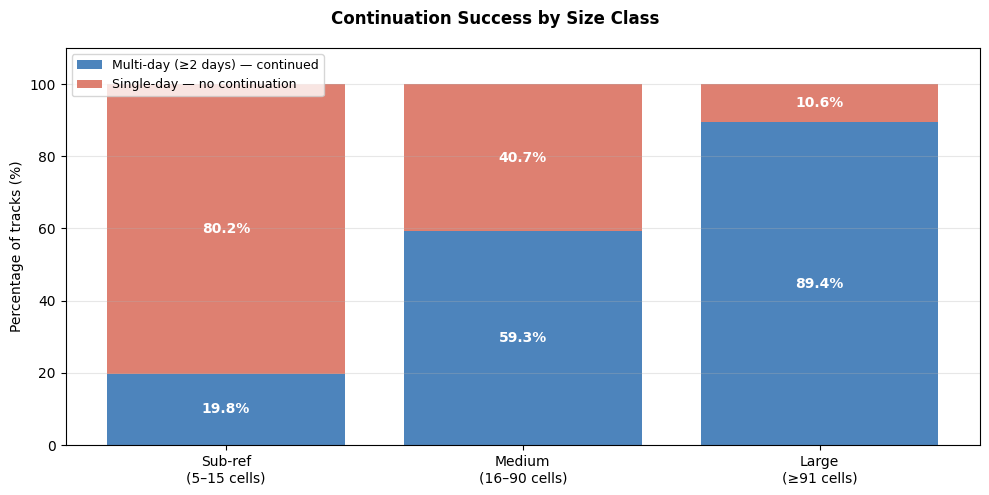

In [17]:
# ── Cell 18 : continuations via overlap vs fallback ───────────────────────────

# count overlap-based vs fallback continuations from track stats
# day_of_track > 0 and not dormant = continuation day
# overlap_fwd stored in row — None/NaN means fallback was used

cont_rows = df_stats[
    (df_stats['day_of_track'] > 0) &
    (~df_stats['dormant'])
].copy()

# overlap_fwd column tells us how the link was made
# if stored as NaN it was a fallback link
if 'overlap_fwd' in cont_rows.columns:
    n_overlap  = cont_rows['overlap_fwd'].notna().sum()
    n_fallback = cont_rows['overlap_fwd'].isna().sum()
else:
    # overlap_fwd not stored — estimate from overlap_lenient
    # recompute by checking if any strict or lenient overlap existed
    # for now report what we can derive from merge/split counts
    total_cont = len(cont_rows)
    print("overlap_fwd column not present — estimating from available data")
    print(f"\nTotal continuation day-rows : {total_cont:,}")
    print(f"Total dormant rows          : {df_stats['dormant'].sum():,}")
    print()

    # alternative: report continuation breakdown by end_type proxy
    # tracks that end as natural_death with duration > 1 used fallback at some point
    dur_gt1 = df_summary[df_summary['duration'] > 1]
    print(f"Tracks with duration > 1 (used overlap or fallback at least once): "
          f"{len(dur_gt1):,}")
    print()

    # show continuation success by size class
    print(f"{'Size class':<25} {'Tracks':>8} {'Mean dur':>10} "
          f"{'% multi-day':>12}")
    print("-" * 58)
    for label, lo, hi in [
        ('Sub-ref (5-15)',  5,  15),
        ('Medium (16-90)', 16, 90),
        ('Large  (≥91)',   91, 9999),
    ]:
        grp = df_summary[df_summary['peak_size'].between(lo, hi)]
        multi = (grp['duration'] > 1).mean() * 100
        print(f"  {label:<23} {len(grp):>8,} {grp['duration'].mean():>10.2f} "
              f"{multi:>11.1f}%")

    # bar chart of continuation vs single-day by size
    fig, ax = plt.subplots(figsize=(10, 5))
    fig.suptitle("Continuation Success by Size Class", fontsize=12, fontweight='bold')

    labels   = ['Sub-ref\n(5–15 cells)', 'Medium\n(16–90 cells)', 'Large\n(≥91 cells)']
    single   = []
    multi    = []
    for lo, hi in [(5,15),(16,90),(91,9999)]:
        grp = df_summary[df_summary['peak_size'].between(lo, hi)]
        single.append((grp['duration'] == 1).mean() * 100)
        multi.append( (grp['duration'] >  1).mean() * 100)

    x = np.arange(len(labels))
    ax.bar(x, multi,  label='Multi-day (≥2 days) — continued',
           color='#2166ac', alpha=0.8)
    ax.bar(x, single, bottom=multi, label='Single-day — no continuation',
           color='#d6604d', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel("Percentage of tracks (%)")
    ax.set_ylim(0, 110)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    for i, (m, s) in enumerate(zip(multi, single)):
        ax.text(i, m/2,       f"{m:.1f}%",  ha='center', va='center',
                color='white', fontweight='bold', fontsize=10)
        ax.text(i, m + s/2,   f"{s:.1f}%",  ha='center', va='center',
                color='white', fontweight='bold', fontsize=10)

    plt.tight_layout()
    plt.savefig('/kaggle/working/continuation_success.png', dpi=150, bbox_inches='tight')
    plt.show()

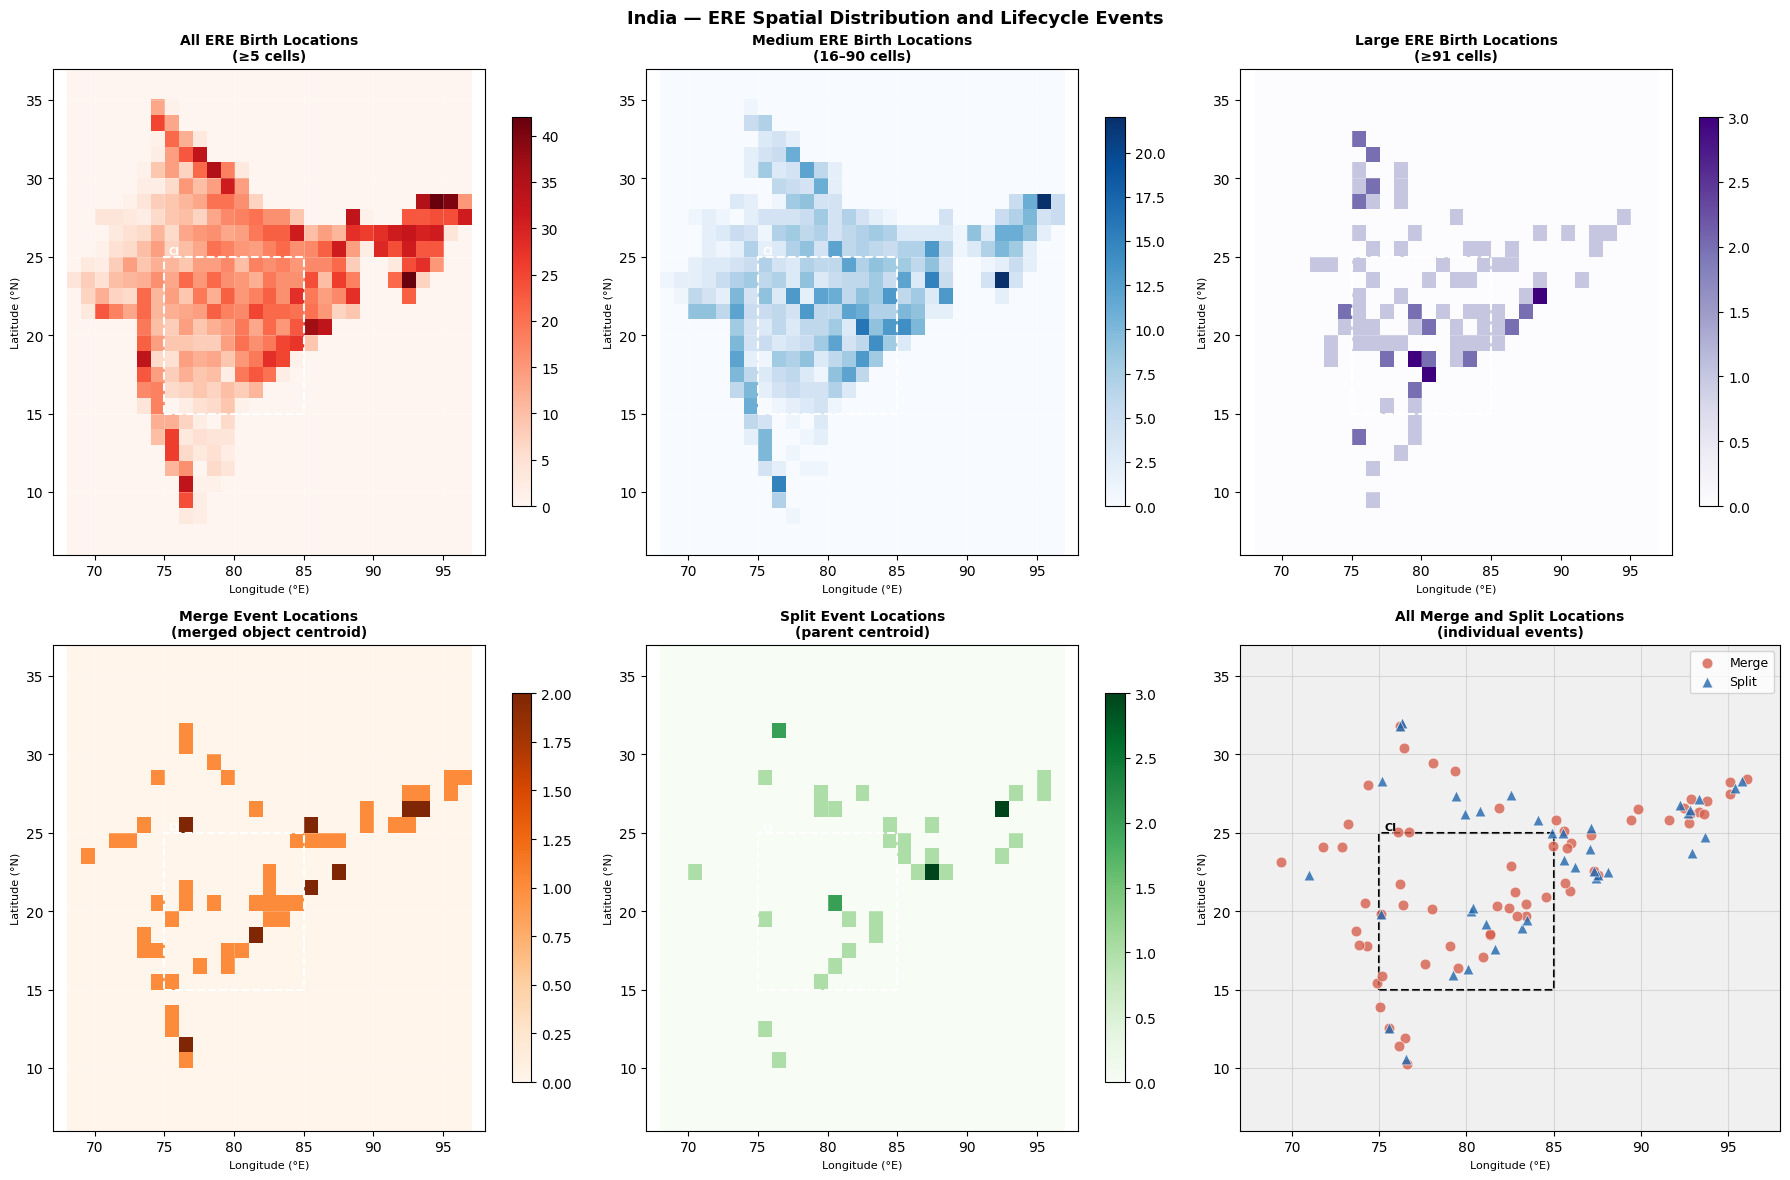

saved → india_maps.png


In [18]:
# ── Cell 19 : India maps — merge/split locations and ERE density ─────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("India — ERE Spatial Distribution and Lifecycle Events",
             fontsize=13, fontweight='bold')

# build density grids at 1° resolution for clarity
lat_bins = np.arange(5, 38, 1.0)
lon_bins = np.arange(68, 98, 1.0)
lat_c    = (lat_bins[:-1] + lat_bins[1:]) / 2
lon_c    = (lon_bins[:-1] + lon_bins[1:]) / 2

def make_density(clats, clons):
    dens, _, _ = np.histogram2d(clats, clons, bins=[lat_bins, lon_bins])
    return dens

def plot_india_map(ax, dens, title, cmap, vmax=None):
    """Simple India map without cartopy — use imshow with extent."""
    vmax = vmax or max(dens.max(), 1)
    im   = ax.imshow(
        dens, origin='lower', aspect='auto',
        extent=[lon_bins[0], lon_bins[-1], lat_bins[0], lat_bins[-1]],
        cmap=cmap, vmin=0, vmax=vmax, interpolation='nearest'
    )
    # India outline — crude but clear
    ax.set_xlim(67, 98)
    ax.set_ylim(6, 37)
    ax.set_xlabel("Longitude (°E)", fontsize=8)
    ax.set_ylabel("Latitude (°N)", fontsize=8)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.grid(alpha=0.3, color='white', lw=0.5)
    # Central India box
    from matplotlib.patches import Rectangle
    ci = Rectangle((75, 15), 10, 10, lw=1.5,
                   edgecolor='white', facecolor='none', ls='--')
    ax.add_patch(ci)
    ax.text(75.3, 25.2, 'CI', color='white', fontsize=7, fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.8)

# ── Panel 1 : all ERE birth locations ────────────────────────────────────────
all_birth_lats = df_summary['birth_lat'].dropna().values
all_birth_lons = df_summary['birth_lon'].dropna().values
dens_all = make_density(all_birth_lats, all_birth_lons)
plot_india_map(axes[0,0], dens_all, "All ERE Birth Locations\n(≥5 cells)", 'Reds')

# ── Panel 2 : medium ERE birth locations ─────────────────────────────────────
med_births = df_summary[df_summary['peak_size'].between(16, 90)]
dens_med   = make_density(med_births['birth_lat'].dropna().values,
                           med_births['birth_lon'].dropna().values)
plot_india_map(axes[0,1], dens_med, "Medium ERE Birth Locations\n(16–90 cells)", 'Blues')

# ── Panel 3 : large ERE birth locations ──────────────────────────────────────
lrg_births = df_summary[df_summary['peak_size'] >= 91]
dens_lrg   = make_density(lrg_births['birth_lat'].dropna().values,
                           lrg_births['birth_lon'].dropna().values)
plot_india_map(axes[0,2], dens_lrg, "Large ERE Birth Locations\n(≥91 cells)", 'Purples')

# ── Panel 4 : merge event locations ──────────────────────────────────────────
dens_merge = make_density(df_merge['centroid_lat'].values,
                           df_merge['centroid_lon'].values)
plot_india_map(axes[1,0], dens_merge, "Merge Event Locations\n(merged object centroid)",
               'Oranges', vmax=max(dens_merge.max(), 1))

# ── Panel 5 : split event locations ──────────────────────────────────────────
dens_split = make_density(df_split['centroid_lat'].values,
                           df_split['centroid_lon'].values)
plot_india_map(axes[1,1], dens_split, "Split Event Locations\n(parent centroid)",
               'Greens', vmax=max(dens_split.max(), 1))

# ── Panel 6 : merge + split together ─────────────────────────────────────────
ax = axes[1, 2]
ax.set_xlim(67, 98)
ax.set_ylim(6, 37)
ax.set_facecolor('#f0f0f0')

# scatter merges and splits as dots
ax.scatter(df_merge['centroid_lon'], df_merge['centroid_lat'],
           c='#d6604d', s=60, alpha=0.8, label='Merge', zorder=3,
           edgecolors='white', linewidths=0.5)
ax.scatter(df_split['centroid_lon'], df_split['centroid_lat'],
           c='#2166ac', s=60, alpha=0.8, label='Split', zorder=3,
           marker='^', edgecolors='white', linewidths=0.5)

from matplotlib.patches import Rectangle
ci = Rectangle((75, 15), 10, 10, lw=1.5,
               edgecolor='black', facecolor='none', ls='--')
ax.add_patch(ci)
ax.text(75.3, 25.2, 'CI', color='black', fontsize=8, fontweight='bold')
ax.set_xlabel("Longitude (°E)", fontsize=8)
ax.set_ylabel("Latitude (°N)", fontsize=8)
ax.set_title("All Merge and Split Locations\n(individual events)", fontsize=10,
             fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.4)

plt.tight_layout()
plt.savefig('/kaggle/working/india_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved → india_maps.png")